# FASE 5 – MACHINE LEARNING NA CABEÇA
## FarmTech Solutions — Previsão de Rendimento de Safra

**Objetivo:** Analisar condições de solo e temperatura para prever o rendimento de safra (regressão supervisionada) e explorar tendências de produtividade via clusterização (aprendizado não supervisionado).

**Dataset:** `crop_yield.csv` — 156 registros de 4 culturas agrícolas.

---

### Estrutura do Notebook
1. Configuração do Ambiente
2. Análise Exploratória de Dados (EDA)
3. Clusterização e Identificação de Outliers
4. Modelagem Preditiva — 5 Algoritmos de Regressão
5. Comparação de Modelos e Conclusões

---
## 1. Configuração do Ambiente

In [32]:
# Instalação das dependências necessárias (caso não estejam instaladas)
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Usuario\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [33]:
# Importação das bibliotecas principais
import pandas as pd                          # Manipulação e análise de dados
import numpy as np                           # Operações numéricas
import matplotlib.pyplot as plt              # Visualizações estáticas
import seaborn as sns                        # Visualizações estatísticas
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento e pipelines
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline

# Algoritmos de Regressão
from sklearn.linear_model import LinearRegression, Ridge           # Modelo 1 e 2
from sklearn.tree import DecisionTreeRegressor                      # Modelo 3
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # Modelos 4 e 5

# Clusterização
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')
PALETTE = 'Set2'

print('✅ Ambiente configurado com sucesso!')

✅ Ambiente configurado com sucesso!


---
## 2. Análise Exploratória de Dados (EDA)

Nesta etapa, buscamos entender a estrutura, qualidade e distribuição dos dados antes de qualquer modelagem.

### 2.1 Carregamento e Visão Geral

In [34]:
# Carregamento do dataset
df = pd.read_csv('raw/crop_yield.csv')

# Renomear colunas para facilitar o manuseio
df.columns = ['Cultura', 'Precipitacao_mm', 'Umidade_Especifica_g_kg',
               'Umidade_Relativa_pct', 'Temperatura_C', 'Rendimento']

print(f'Dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Culturas presentes: {df["Cultura"].nunique()} — {df["Cultura"].unique().tolist()}')
df.head(10)

Dimensões do dataset: 156 linhas × 6 colunas
Culturas presentes: 4 — ['Cocoa, beans', 'Oil palm fruit', 'Rice, paddy', 'Rubber, natural']


,Cultura,Precipitacao_mm,Umidade_Especifica_g_kg,Umidade_Relativa_pct,Temperatura_C,Rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [35]:
# Tipos de dados e valores nulos
print('--- Tipos de Dados e Valores Nulos ---')
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Nulos (%)': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print(info)

--- Tipos de Dados e Valores Nulos ---
                            Tipo  Nulos  Nulos (%)  Únicos
Cultura                   object      0        0.0       4
Precipitacao_mm          float64      0        0.0      39
Umidade_Especifica_g_kg  float64      0        0.0      33
Umidade_Relativa_pct     float64      0        0.0      38
Temperatura_C            float64      0        0.0      29
Rendimento                 int64      0        0.0     155


> **Observação:** O dataset não apresenta valores nulos em nenhuma das colunas, o que elimina a necessidade de imputação. A coluna `Cultura` é categórica e será codificada para os modelos preditivos.

In [36]:
# Estatísticas descritivas completas
print('--- Estatísticas Descritivas ---')
df.describe().round(2)

--- Estatísticas Descritivas ---


,Precipitacao_mm,Umidade_Especifica_g_kg,Umidade_Relativa_pct,Temperatura_C,Rendimento
count,156.00,156.00,156.00,156.00,156.00
mean,2486.50,18.20,84.74,26.18,56153.10
std,289.46,0.29,1.00,0.26,70421.96
min,1934.62,17.54,82.11,25.56,5249.00
25%,2302.99,18.03,84.12,26.02,8327.75
50%,2424.55,18.27,84.85,26.13,18871.00
75%,2718.08,18.40,85.51,26.30,67518.75
max,3085.79,18.70,86.10,26.81,203399.00


### 2.2 Distribuição das Culturas

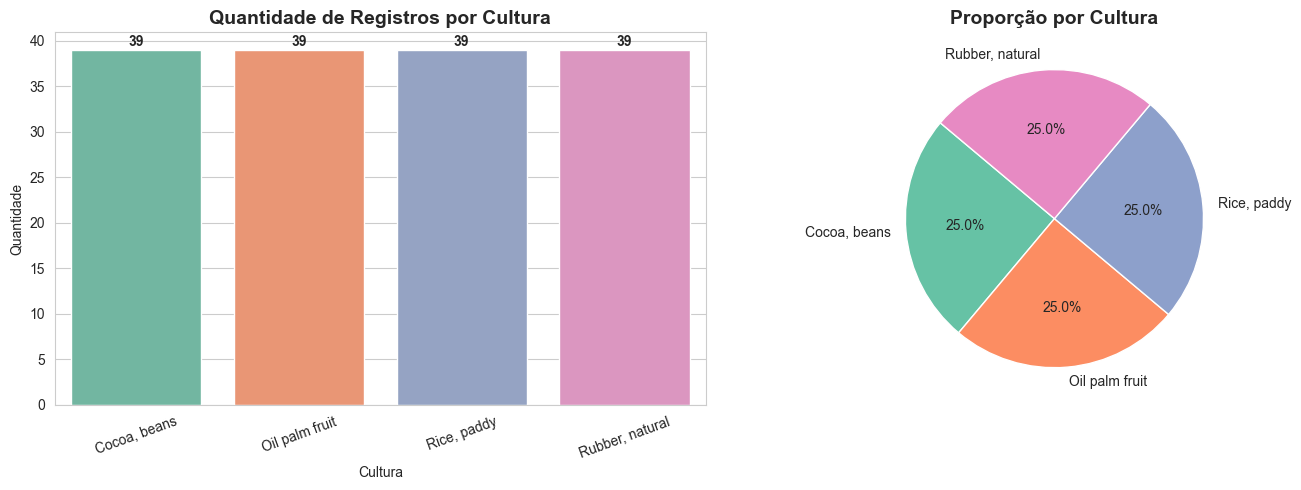

Cultura
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64


In [37]:
# Contagem de registros por cultura
contagem = df['Cultura'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sns.barplot(x=contagem.index, y=contagem.values, palette=PALETTE, ax=axes[0])
axes[0].set_title('Quantidade de Registros por Cultura', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cultura')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(contagem.values, labels=contagem.index, autopct='%1.1f%%',
             colors=sns.color_palette(PALETTE, len(contagem)),
             startangle=140)
axes[1].set_title('Proporção por Cultura', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribuicao_culturas.png', dpi=150, bbox_inches='tight')
plt.show()
print(contagem)

> **Observação:** O dataset apresenta 4 culturas com distribuição equilibrada: **Cocoa beans** (39 registros), **Rice, paddy** (39), **Rubber, natural** (39) e **Oil palm fruit** (39). O balanceamento evita viés nos modelos supervisionados.

### 2.3 Distribuição das Variáveis Numéricas

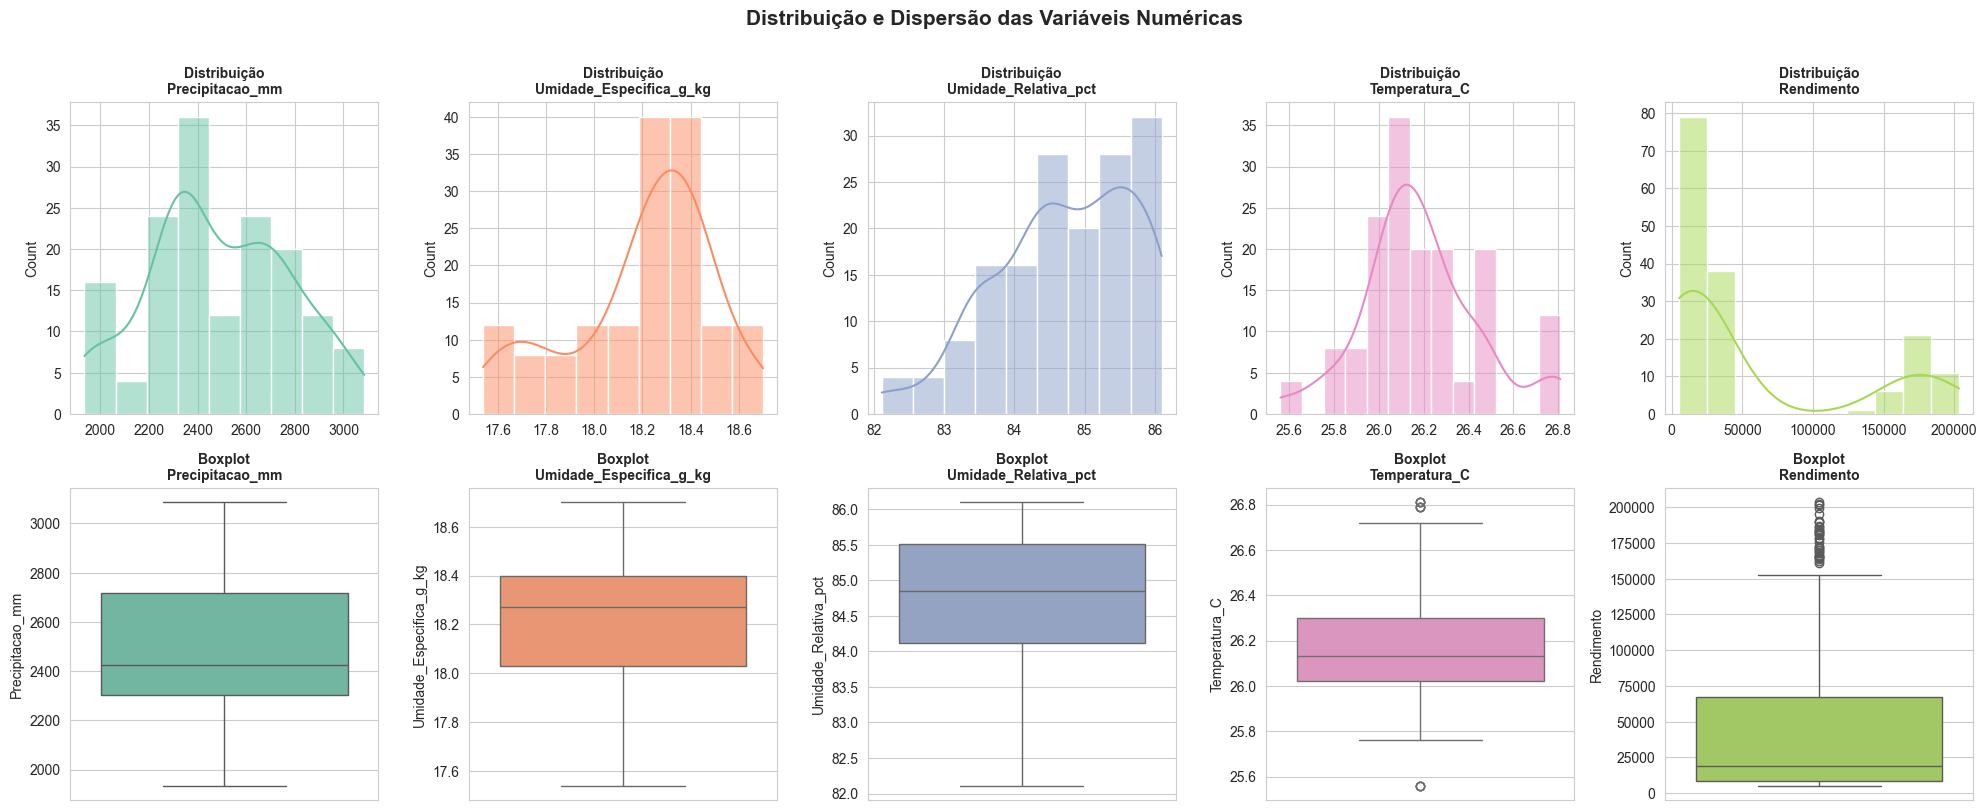

In [38]:
# Colunas numéricas
cols_num = ['Precipitacao_mm', 'Umidade_Especifica_g_kg', 'Umidade_Relativa_pct',
            'Temperatura_C', 'Rendimento']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(cols_num):
    # Histograma com KDE
    sns.histplot(df[col], kde=True, ax=axes[0, i], color=sns.color_palette(PALETTE)[i])
    axes[0, i].set_title(f'Distribuição\n{col}', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('')

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[1, i], color=sns.color_palette(PALETTE)[i])
    axes[1, i].set_title(f'Boxplot\n{col}', fontsize=10, fontweight='bold')

plt.suptitle('Distribuição e Dispersão das Variáveis Numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribuicao_variaveis.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observação:** 
> - `Rendimento` apresenta distribuição multimodal (refletindo as diferentes culturas com escalas distintas de produção).
> - `Precipitacao_mm` tem maior dispersão, com possíveis outliers na cauda superior.
> - As variáveis de temperatura e umidade são mais compactas e bem distribuídas.

### 2.4 Rendimento por Cultura

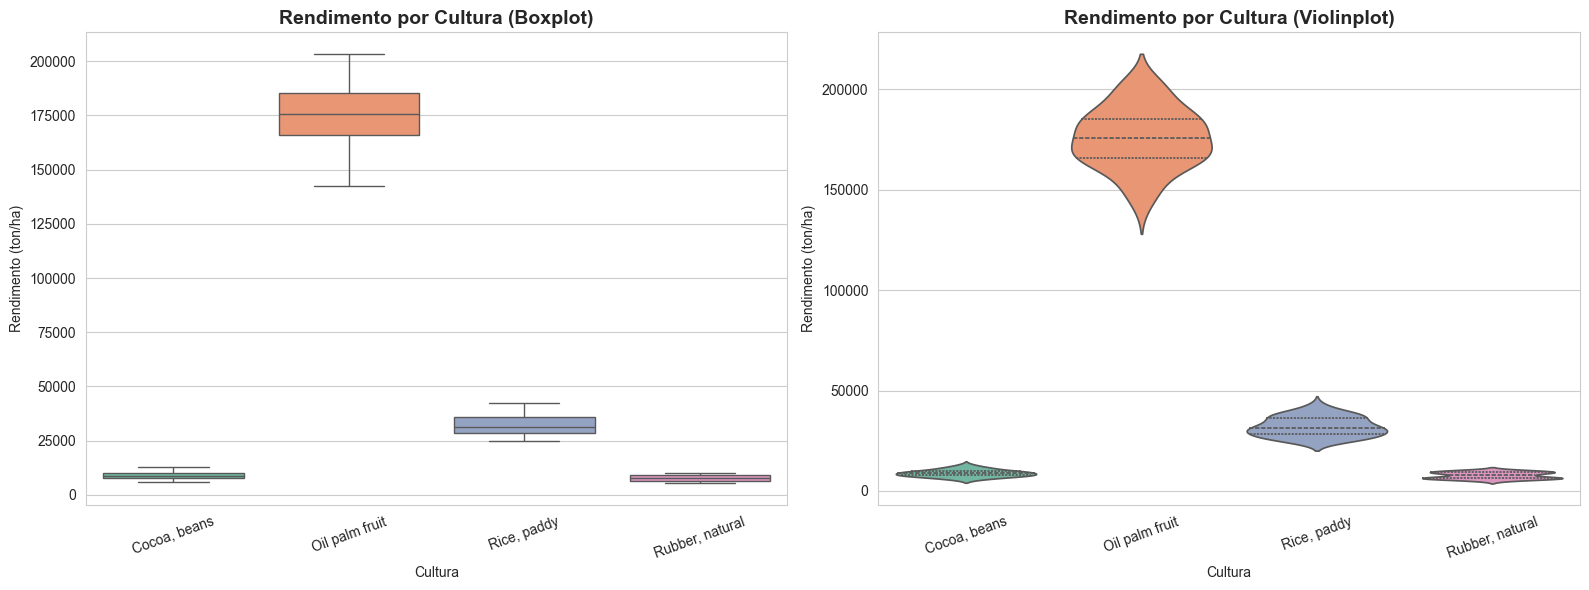

--- Estatísticas de Rendimento por Cultura ---


,mean,median,std,min,max
Cultura,,,,,
"Cocoa, beans",8883.0,8848.0,1745.0,5765,13056
Oil palm fruit,175805.0,175629.0,14920.0,142425,203399
"Rice, paddy",32100.0,31101.0,4790.0,24686,42550
"Rubber, natural",7825.0,7817.0,1600.0,5249,10285


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot do rendimento por cultura
sns.boxplot(data=df, x='Cultura', y='Rendimento', palette=PALETTE, ax=axes[0])
axes[0].set_title('Rendimento por Cultura (Boxplot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cultura')
axes[0].set_ylabel('Rendimento (ton/ha)')
axes[0].tick_params(axis='x', rotation=20)

# Violinplot
sns.violinplot(data=df, x='Cultura', y='Rendimento', palette=PALETTE, ax=axes[1], inner='quartile')
axes[1].set_title('Rendimento por Cultura (Violinplot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cultura')
axes[1].set_ylabel('Rendimento (ton/ha)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('rendimento_por_cultura.png', dpi=150, bbox_inches='tight')
plt.show()

# Estatísticas por cultura
print('--- Estatísticas de Rendimento por Cultura ---')
df.groupby('Cultura')['Rendimento'].agg(['mean', 'median', 'std', 'min', 'max']).round(0)

> **Observação:**
> - **Oil palm fruit** apresenta os maiores rendimentos absolutos, com média significativamente acima das demais culturas.
> - **Cocoa beans** e **Rubber, natural** têm rendimentos intermediários.
> - **Rice, paddy** apresenta os menores rendimentos. A diferença de escala entre culturas é uma característica inerente ao tipo de produto agrícola e deve ser considerada na modelagem.

### 2.5 Análise de Correlação

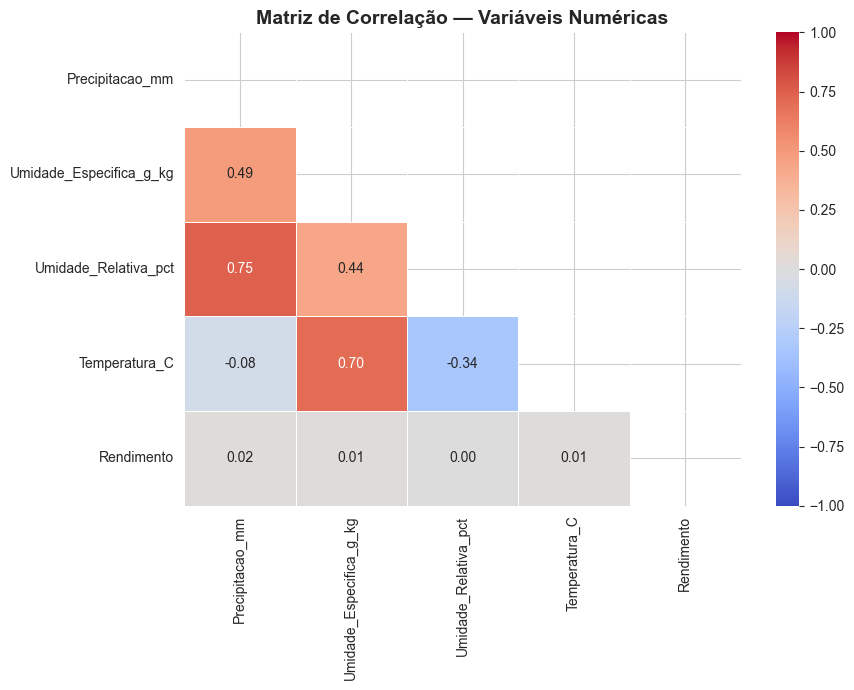

--- Correlação com Rendimento ---
Precipitacao_mm            0.018830
Temperatura_C              0.013007
Umidade_Especifica_g_kg    0.012651
Umidade_Relativa_pct       0.000008


In [40]:
# Matriz de correlação (apenas variáveis numéricas)
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Máscara para mostrar apenas o triângulo inferior
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlação com o alvo
print('--- Correlação com Rendimento ---')
corr_alvo = df[cols_num].corr()['Rendimento'].drop('Rendimento').sort_values(ascending=False)
print(corr_alvo.to_string())

> **Observação:** As correlações lineares individuais com `Rendimento` são relativamente fracas, o que sugere que a variável `Cultura` (categórica) tem papel determinante na predição — afinal, cada cultura tem uma escala de rendimento completamente diferente. Isso justifica a inclusão da feature `Cultura` codificada nos modelos.

### 2.6 Relações entre Features e Rendimento por Cultura

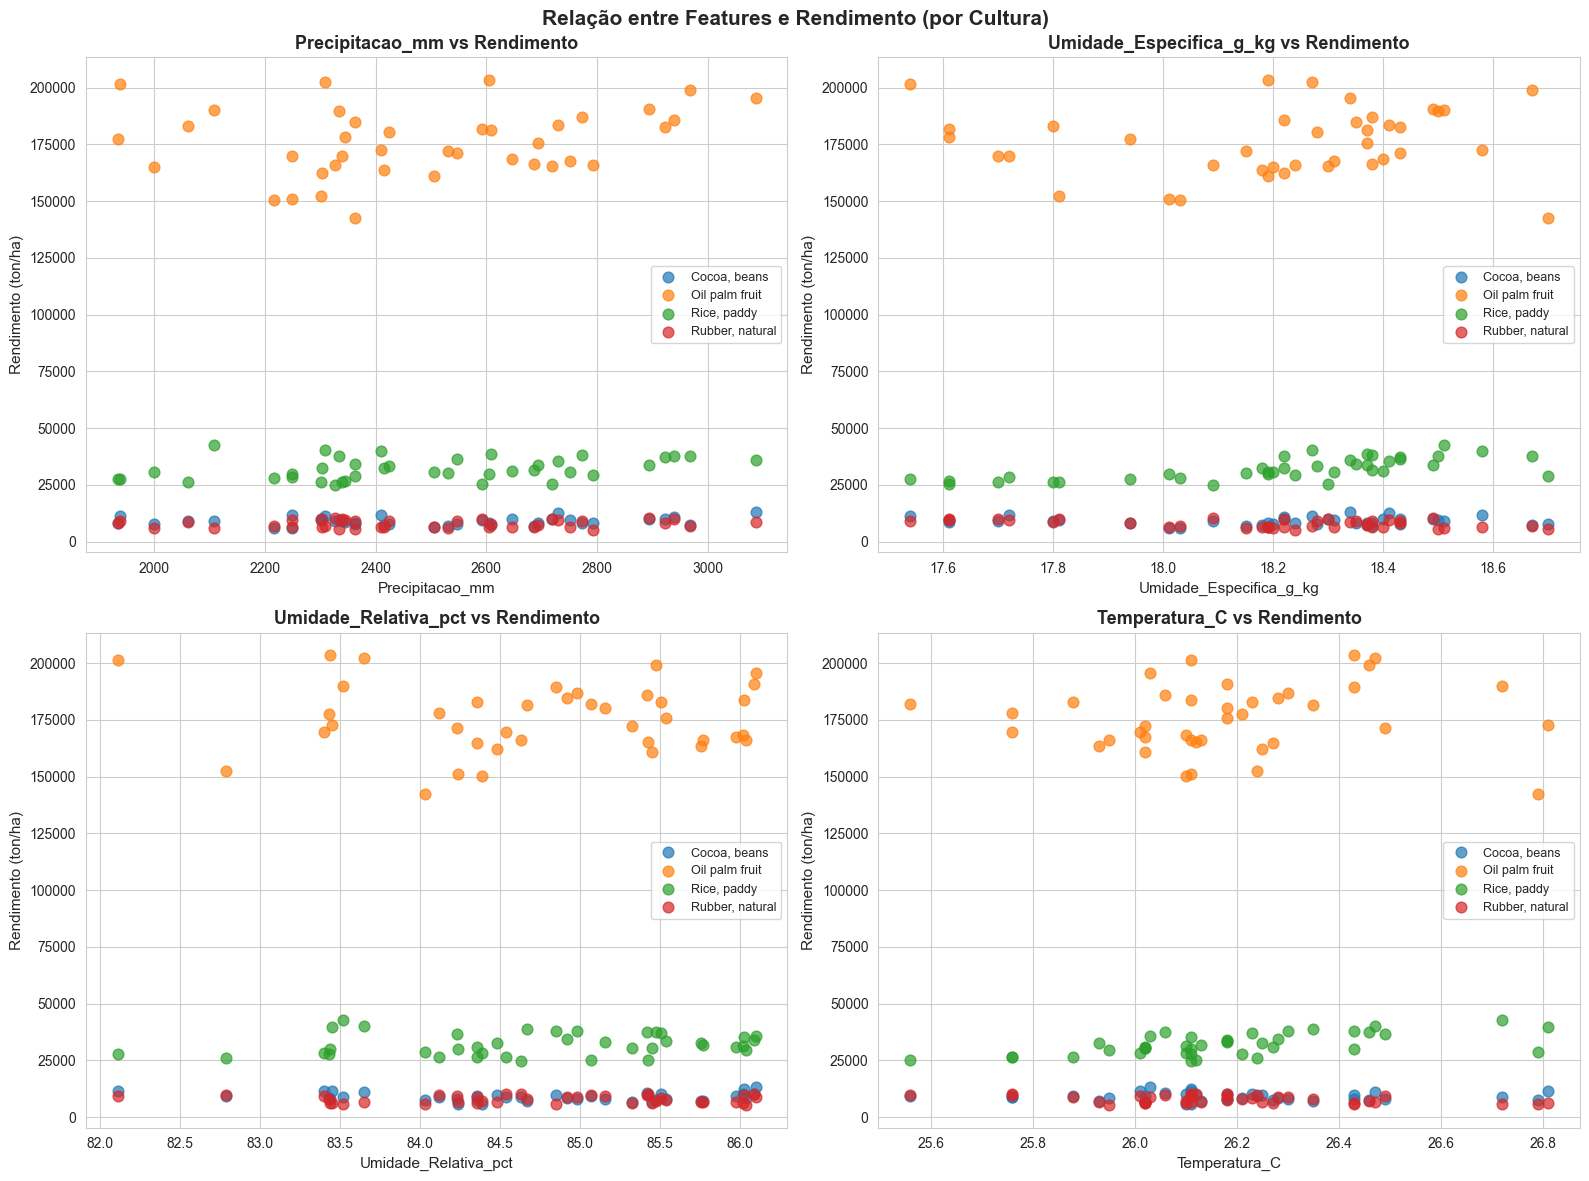

In [41]:
# Scatter plots das features vs Rendimento, coloridos por Cultura
features_plot = ['Precipitacao_mm', 'Umidade_Especifica_g_kg', 'Umidade_Relativa_pct', 'Temperatura_C']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_plot):
    for cultura in df['Cultura'].unique():
        subset = df[df['Cultura'] == cultura]
        axes[i].scatter(subset[feature], subset['Rendimento'], label=cultura, alpha=0.7, s=60)
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel('Rendimento (ton/ha)', fontsize=11)
    axes[i].set_title(f'{feature} vs Rendimento', fontsize=13, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Relação entre Features e Rendimento (por Cultura)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_features.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observação:** A segmentação por cultura revela que os clusters naturais de rendimento correspondem diretamente ao tipo de cultura. Oil palm fruit destaca-se com rendimentos muito superiores. As relações dentro de cada cultura são mais interpretáveis do que no conjunto geral, reforçando a importância da variável `Cultura` como preditor.

---
## 3. Clusterização e Identificação de Outliers

Utilizamos aprendizado não supervisionado (K-Means) para encontrar tendências de produtividade e identificar cenários discrepantes.

### 3.1 Pré-processamento para Clusterização

In [42]:
# Codificação da variável categórica para clusterização
le = LabelEncoder()
df['Cultura_cod'] = le.fit_transform(df['Cultura'])

# Features para clusterização (todas as variáveis numéricas incluindo rendimento)
features_cluster = ['Cultura_cod', 'Precipitacao_mm', 'Umidade_Especifica_g_kg',
                    'Umidade_Relativa_pct', 'Temperatura_C', 'Rendimento']

X_cluster = df[features_cluster].copy()

# Normalização para K-Means (sensível à escala)
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print('Features para clusterização:', features_cluster)
print(f'Dimensões: {X_cluster_scaled.shape}')

Features para clusterização: ['Cultura_cod', 'Precipitacao_mm', 'Umidade_Especifica_g_kg', 'Umidade_Relativa_pct', 'Temperatura_C', 'Rendimento']
Dimensões: (156, 6)


### 3.2 Método do Cotovelo — Número Ideal de Clusters

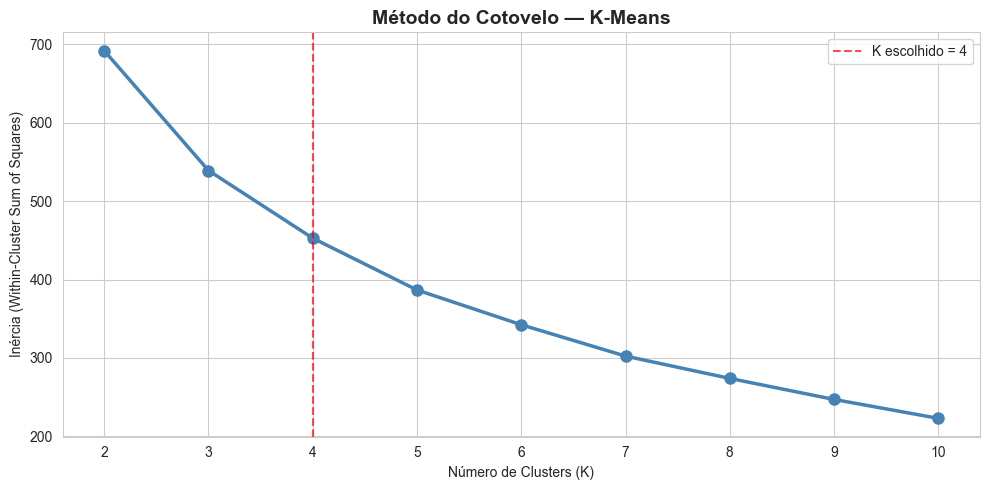

Inércias por K: {2: 692.0, 3: 539.0, 4: 453.0, 5: 387.0, 6: 342.0, 7: 302.0, 8: 274.0, 9: 247.0, 10: 223.0}


In [43]:
# Método do Cotovelo (Elbow Method) para definir o K ideal
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

# Plot do cotovelo
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, inertias, marker='o', linewidth=2.5, markersize=8, color='steelblue')
ax.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K escolhido = 4')
ax.set_title('Método do Cotovelo — K-Means', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Clusters (K)')
ax.set_ylabel('Inércia (Within-Cluster Sum of Squares)')
ax.legend()
plt.tight_layout()
plt.savefig('cotovelo.png', dpi=150, bbox_inches='tight')
plt.show()

print('Inércias por K:', dict(zip(k_range, [round(i, 0) for i in inertias])))

> **Observação:** O cotovelo é identificado em torno de **K=4**, o que é altamente coerente com o número de culturas distintas no dataset. Isso confirma que o principal fator de agrupamento dos dados é mesmo o tipo de cultura.

### 3.3 K-Means com K=4

In [44]:
# Treinamento do K-Means com 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

# Redução dimensional para visualização 2D (PCA)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

variancia = pca.explained_variance_ratio_
print(f'Variância explicada — PC1: {variancia[0]:.2%} | PC2: {variancia[1]:.2%}')
print(f'Total explicado: {sum(variancia):.2%}')

Variância explicada — PC1: 35.69% | PC2: 26.62%
Total explicado: 62.30%


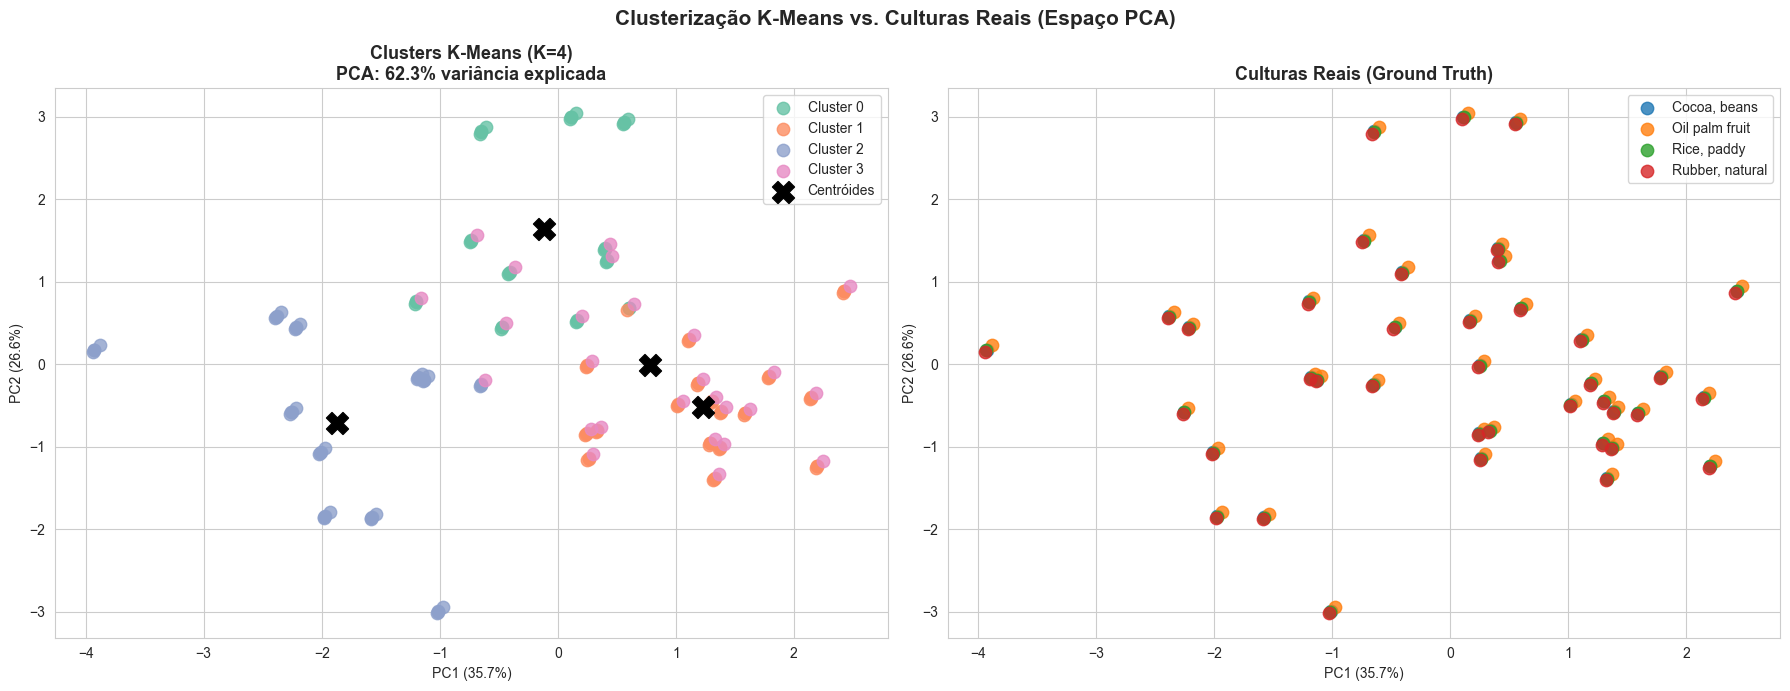

In [45]:
# Visualização dos clusters no espaço PCA
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Por Cluster K-Means
cores_cluster = sns.color_palette(PALETTE, 4)
for c in range(4):
    mask = df['Cluster'] == c
    axes[0].scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                    label=f'Cluster {c}', s=80, alpha=0.8, color=cores_cluster[c])
# Centróides
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='X', s=250, color='black', zorder=5, label='Centróides')
axes[0].set_title(f'Clusters K-Means (K=4)\nPCA: {sum(variancia):.1%} variância explicada',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({variancia[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({variancia[1]:.1%})')
axes[0].legend()

# Por Cultura Real
cores_cultura = sns.color_palette('tab10', df['Cultura'].nunique())
for i, cultura in enumerate(df['Cultura'].unique()):
    mask = df['Cultura'] == cultura
    axes[1].scatter(df.loc[mask, 'PCA1'], df.loc[mask, 'PCA2'],
                    label=cultura, s=80, alpha=0.8, color=cores_cultura[i])
axes[1].set_title('Culturas Reais (Ground Truth)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({variancia[0]:.1%})')
axes[1].set_ylabel(f'PC2 ({variancia[1]:.1%})')
axes[1].legend()

plt.suptitle('Clusterização K-Means vs. Culturas Reais (Espaço PCA)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Perfil médio de cada cluster
print('--- Perfil Médio dos Clusters ---')
perfil = df.groupby('Cluster')[['Precipitacao_mm', 'Umidade_Especifica_g_kg',
                                  'Umidade_Relativa_pct', 'Temperatura_C', 'Rendimento']].mean().round(2)
print(perfil)
print()

# Correspondência cluster × cultura dominante
print('--- Cultura Dominante por Cluster ---')
print(df.groupby(['Cluster', 'Cultura']).size().unstack(fill_value=0))

--- Perfil Médio dos Clusters ---
         Precipitacao_mm  Umidade_Especifica_g_kg  Umidade_Relativa_pct  \
Cluster                                                                   
0                2346.35                    18.41                 84.09   
1                2731.10                    18.34                 85.63   
2                2230.03                    17.80                 83.90   
3                2610.11                    18.32                 85.20   

         Temperatura_C  Rendimento  
Cluster                             
0                26.51    30295.83  
1                26.12    16454.63  
2                25.98    51344.74  
3                26.20   178310.15  

--- Cultura Dominante por Cluster ---
Cultura  Cocoa, beans  Oil palm fruit  Rice, paddy  Rubber, natural
Cluster                                                            
0                  11               3           11               10
1                  17               0           17

> **Observação:** Os clusters K-Means correspondem bem às culturas reais, confirmando que as condições ambientais (precipitação, umidade, temperatura) formam grupos naturais alinhados ao tipo de cultura. Cada cluster representa um **cenário agroclimático distinto** com seu próprio nível de produtividade.

### 3.4 Detecção de Outliers — Método IQR

In [47]:
# Detecção de outliers via Intervalo Interquartil (IQR) por cultura
# Aplicamos por cultura pois as escalas de rendimento são bem distintas

outliers_total = pd.DataFrame()

print('--- Outliers por Cultura (Rendimento, IQR) ---')
for cultura in df['Cultura'].unique():
    subset = df[df['Cultura'] == cultura]['Rendimento']
    Q1 = subset.quantile(0.25)
    Q3 = subset.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    
    outliers = df[(df['Cultura'] == cultura) &
                  ((df['Rendimento'] < limite_inf) | (df['Rendimento'] > limite_sup))]
    
    print(f'  {cultura}: Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f} '
          f'| Limites: [{limite_inf:.0f}, {limite_sup:.0f}] '
          f'| Outliers: {len(outliers)}')
    
    outliers_total = pd.concat([outliers_total, outliers])

print(f'\nTotal de outliers identificados: {len(outliers_total)}')
if len(outliers_total) > 0:
    print(outliers_total[['Cultura', 'Rendimento']].to_string())

--- Outliers por Cultura (Rendimento, IQR) ---
  Cocoa, beans: Q1=7729, Q3=9918, IQR=2189 | Limites: [4446, 13202] | Outliers: 0
  Oil palm fruit: Q1=166018, Q3=185230, IQR=19212 | Limites: [137199, 214049] | Outliers: 0
  Rice, paddy: Q1=28294, Q3=36098, IQR=7805 | Limites: [16586, 47806] | Outliers: 0
  Rubber, natural: Q1=6398, Q3=9272, IQR=2874 | Limites: [2086, 13584] | Outliers: 0

Total de outliers identificados: 0


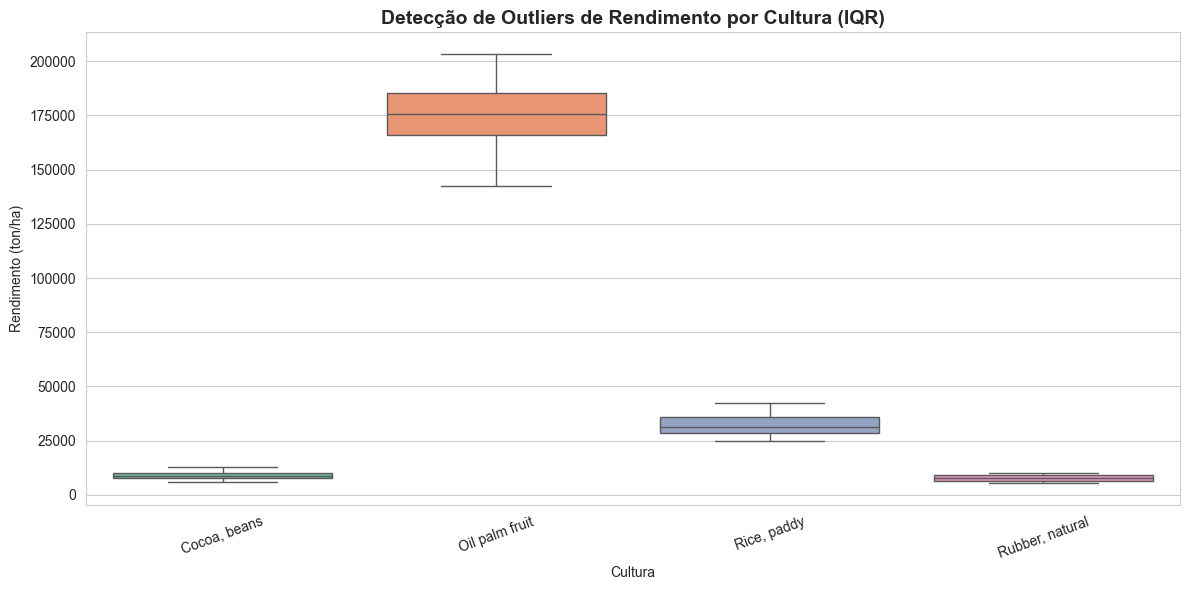

In [48]:
# Visualização de outliers nos boxplots por cultura
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='Cultura', y='Rendimento', palette=PALETTE, ax=ax,
            flierprops=dict(marker='o', color='red', markersize=10, label='Outlier'))
ax.set_title('Detecção de Outliers de Rendimento por Cultura (IQR)', fontsize=14, fontweight='bold')
ax.set_xlabel('Cultura')
ax.set_ylabel('Rendimento (ton/ha)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('outliers.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observação:** A análise de outliers por cultura via método IQR permite identificar registros de rendimento anormalmente altos ou baixos dentro de cada tipo de cultura, controlando o viés de escala entre culturas. Pontos fora dos limites representam condições excepcionais de produção (safras muito boas ou muito ruins) que podem indicar eventos climáticos extremos ou práticas agrícolas atípicas.

---
## 4. Modelagem Preditiva — 5 Algoritmos de Regressão

Seguindo as boas práticas de Machine Learning, construímos um pipeline completo: pré-processamento → divisão treino/teste → treinamento → avaliação com métricas.

### 4.1 Pré-processamento para Modelagem Supervisionada

In [49]:
# Features (X) e variável alvo (y)
features_modelo = ['Cultura_cod', 'Precipitacao_mm', 'Umidade_Especifica_g_kg',
                   'Umidade_Relativa_pct', 'Temperatura_C']

X = df[features_modelo].copy()
y = df['Rendimento'].copy()

print(f'Features: {features_modelo}')
print(f'Alvo: Rendimento | Shape X: {X.shape} | Shape y: {y.shape}')

# Divisão treino/teste: 80% treino, 20% teste
# Estratificado por cultura para garantir representação balanceada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['Cultura_cod']
)

print(f'\nTreino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')
print(f'Proporção de cada cultura no treino:')
print(pd.Series(le.inverse_transform(X_train['Cultura_cod'])).value_counts().to_string())

Features: ['Cultura_cod', 'Precipitacao_mm', 'Umidade_Especifica_g_kg', 'Umidade_Relativa_pct', 'Temperatura_C']
Alvo: Rendimento | Shape X: (156, 5) | Shape y: (156,)

Treino: 124 amostras | Teste: 32 amostras
Proporção de cada cultura no treino:
Cocoa, beans       31
Oil palm fruit     31
Rubber, natural    31
Rice, paddy        31


### 4.2 Definição dos Modelos e Função de Avaliação

In [50]:
def avaliar_modelo(nome, modelo, X_train, X_test, y_train, y_test, scaler=None):
    """Treina e avalia um modelo de regressão, retornando métricas completas."""
    
    # Normalização opcional
    if scaler:
        X_tr = scaler.fit_transform(X_train)
        X_te = scaler.transform(X_test)
    else:
        X_tr, X_te = X_train, X_test
    
    # Treinamento
    modelo.fit(X_tr, y_train)
    
    # Predições no conjunto de teste
    y_pred = modelo.predict(X_te)
    
    # Predições no treino (para checar overfitting)
    y_pred_train = modelo.predict(X_tr)
    
    # Métricas no conjunto de teste
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    # R² no treino (para análise de overfitting)
    r2_train = r2_score(y_train, y_pred_train)
    
    # Cross-validation (5 folds)
    cv_scores = cross_val_score(modelo, X_tr, y_train, cv=5, scoring='r2')
    
    print(f'\n{'='*55}')
    print(f'  Modelo: {nome}')
    print(f'{'='*55}')
    print(f'  MAE   (Erro Médio Absoluto):   {mae:>12,.2f} ton/ha')
    print(f'  RMSE  (Raiz do Erro Quadrático): {rmse:>10,.2f} ton/ha')
    print(f'  R²    (Coeficiente de Det.):   {r2:>12.4f}')
    print(f'  R²    Treino:                  {r2_train:>12.4f}')
    print(f'  R²    Cross-Val (5-fold):      {cv_scores.mean():>12.4f} ± {cv_scores.std():.4f}')
    
    return {
        'Modelo': nome,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2_Teste': round(r2, 4),
        'R2_Treino': round(r2_train, 4),
        'R2_CV_Media': round(cv_scores.mean(), 4),
        'R2_CV_Std': round(cv_scores.std(), 4),
        'y_pred': y_pred
    }

# Dicionário para armazenar resultados
resultados = []

print('Função de avaliação definida. Iniciando treinamento dos modelos...')

Função de avaliação definida. Iniciando treinamento dos modelos...


### 4.3 Modelo 1 — Regressão Linear

**Descrição:** Modelo paramétrico clássico que assume relação linear entre features e alvo. Serve como **baseline** para comparação.

In [51]:
# Regressão Linear requer normalização das features
scaler_lr = StandardScaler()
modelo_lr = LinearRegression()

res_lr = avaliar_modelo(
    'Regressão Linear (Baseline)',
    modelo_lr, X_train, X_test, y_train, y_test,
    scaler=scaler_lr
)
resultados.append({k: v for k, v in res_lr.items() if k != 'y_pred'})

# Coeficientes do modelo
coeficientes = pd.Series(modelo_lr.coef_, index=features_modelo)
print(f'\n  Intercepto: {modelo_lr.intercept_:,.2f}')
print(f'  Coeficientes:')
print(coeficientes.sort_values(ascending=False).to_string())


  Modelo: Regressão Linear (Baseline)
  MAE   (Erro Médio Absoluto):      56,135.88 ton/ha
  RMSE  (Raiz do Erro Quadrático):  67,420.80 ton/ha
  R²    (Coeficiente de Det.):         0.0027
  R²    Treino:                        0.0632
  R²    Cross-Val (5-fold):           -0.0917 ± 0.0556

  Intercepto: 56,420.52
  Coeficientes:
Umidade_Especifica_g_kg    54254.391994
Precipitacao_mm             7016.057918
Cultura_cod               -16750.479359
Umidade_Relativa_pct      -42642.987378
Temperatura_C             -47231.430235


> **Interpretação:** O coeficiente de `Cultura_cod` ser o mais relevante confirma que o tipo de cultura é o maior determinante do rendimento. Os coeficientes lineares capturam relações médias, mas podem não capturar não-linearidades presentes nos dados.

### 4.4 Modelo 2 — Ridge (Regressão Linear Regularizada)

**Descrição:** Variante da Regressão Linear com regularização L2 (Ridge), que penaliza coeficientes grandes para reduzir overfitting em dados com multicolinearidade.

In [52]:
scaler_ridge = StandardScaler()
modelo_ridge = Ridge(alpha=10.0, random_state=42)  # alpha controla a intensidade da regularização

res_ridge = avaliar_modelo(
    'Ridge (Regressão Linear Regularizada L2)',
    modelo_ridge, X_train, X_test, y_train, y_test,
    scaler=scaler_ridge
)
resultados.append({k: v for k, v in res_ridge.items() if k != 'y_pred'})


  Modelo: Ridge (Regressão Linear Regularizada L2)
  MAE   (Erro Médio Absoluto):      56,147.48 ton/ha
  RMSE  (Raiz do Erro Quadrático):  67,185.74 ton/ha
  R²    (Coeficiente de Det.):         0.0097
  R²    Treino:                        0.0623
  R²    Cross-Val (5-fold):           -0.0688 ± 0.0398


### 4.5 Modelo 3 — Árvore de Decisão (Decision Tree)

**Descrição:** Algoritmo não-paramétrico que aprende regras hierárquicas de decisão. Captura relações não-lineares e interações entre features.

In [53]:
# Árvore de Decisão com profundidade controlada para evitar overfitting
modelo_dt = DecisionTreeRegressor(
    max_depth=8,          # Limita a profundidade da árvore
    min_samples_split=5,  # Mínimo de amostras para dividir um nó
    min_samples_leaf=3,   # Mínimo de amostras em folha
    random_state=42
)

res_dt = avaliar_modelo(
    'Árvore de Decisão (Decision Tree)',
    modelo_dt, X_train, X_test, y_train, y_test
)
resultados.append({k: v for k, v in res_dt.items() if k != 'y_pred'})

# Importância das features
importancias = pd.Series(modelo_dt.feature_importances_, index=features_modelo).sort_values(ascending=False)
print(f'\n  Importância das Features:')
for feat, imp in importancias.items():
    barra = '█' * int(imp * 40)
    print(f'    {feat:<35}: {imp:.4f}  {barra}')


  Modelo: Árvore de Decisão (Decision Tree)
  MAE   (Erro Médio Absoluto):       5,731.45 ton/ha
  RMSE  (Raiz do Erro Quadrático):  11,113.31 ton/ha
  R²    (Coeficiente de Det.):         0.9729
  R²    Treino:                        0.9965
  R²    Cross-Val (5-fold):            0.9753 ± 0.0149

  Importância das Features:
    Cultura_cod                        : 0.9913  ███████████████████████████████████████
    Temperatura_C                      : 0.0033  
    Precipitacao_mm                    : 0.0030  
    Umidade_Especifica_g_kg            : 0.0019  
    Umidade_Relativa_pct               : 0.0006  


### 4.6 Modelo 4 — Random Forest

**Descrição:** Ensemble de múltiplas árvores de decisão treinadas com amostras e features aleatórias. Mais robusto que uma única árvore, reduz overfitting via bagging.

In [54]:
modelo_rf = RandomForestRegressor(
    n_estimators=200,     # Número de árvores no ensemble
    max_depth=10,         # Profundidade máxima de cada árvore
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',  # Subconjunto aleatório de features em cada split
    random_state=42,
    n_jobs=-1             # Utiliza todos os núcleos disponíveis
)

res_rf = avaliar_modelo(
    'Random Forest',
    modelo_rf, X_train, X_test, y_train, y_test
)
resultados.append({k: v for k, v in res_rf.items() if k != 'y_pred'})

# Importância das features
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=features_modelo).sort_values(ascending=False)
print(f'\n  Importância das Features (Random Forest):')
for feat, imp in importancias_rf.items():
    barra = '█' * int(imp * 40)
    print(f'    {feat:<35}: {imp:.4f}  {barra}')


  Modelo: Random Forest
  MAE   (Erro Médio Absoluto):      24,203.70 ton/ha
  RMSE  (Raiz do Erro Quadrático):  30,141.99 ton/ha
  R²    (Coeficiente de Det.):         0.8007
  R²    Treino:                        0.9200
  R²    Cross-Val (5-fold):            0.7141 ± 0.0399

  Importância das Features (Random Forest):
    Cultura_cod                        : 0.7851  ███████████████████████████████
    Precipitacao_mm                    : 0.0677  ██
    Umidade_Relativa_pct               : 0.0556  ██
    Umidade_Especifica_g_kg            : 0.0474  █
    Temperatura_C                      : 0.0442  █


### 4.7 Modelo 5 — Gradient Boosting

**Descrição:** Algoritmo de boosting que constrói árvores sequencialmente, onde cada nova árvore corrige os erros da anterior. Geralmente produz as melhores métricas preditivas entre os algoritmos de ensemble.

In [55]:
modelo_gb = GradientBoostingRegressor(
    n_estimators=200,        # Número de estimadores (árvores)
    learning_rate=0.05,      # Taxa de aprendizado (menor = mais conservador)
    max_depth=5,             # Profundidade de cada árvore
    subsample=0.8,           # Fração de amostras por iteração (reduz overfitting)
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42
)

res_gb = avaliar_modelo(
    'Gradient Boosting',
    modelo_gb, X_train, X_test, y_train, y_test
)
resultados.append({k: v for k, v in res_gb.items() if k != 'y_pred'})

# Importância das features
importancias_gb = pd.Series(modelo_gb.feature_importances_, index=features_modelo).sort_values(ascending=False)
print(f'\n  Importância das Features (Gradient Boosting):')
for feat, imp in importancias_gb.items():
    barra = '█' * int(imp * 40)
    print(f'    {feat:<35}: {imp:.4f}  {barra}')


  Modelo: Gradient Boosting
  MAE   (Erro Médio Absoluto):       5,153.60 ton/ha
  RMSE  (Raiz do Erro Quadrático):  10,142.21 ton/ha
  R²    (Coeficiente de Det.):         0.9774
  R²    Treino:                        0.9997
  R²    Cross-Val (5-fold):            0.9872 ± 0.0079

  Importância das Features (Gradient Boosting):
    Cultura_cod                        : 0.9844  ███████████████████████████████████████
    Precipitacao_mm                    : 0.0048  
    Temperatura_C                      : 0.0042  
    Umidade_Especifica_g_kg            : 0.0039  
    Umidade_Relativa_pct               : 0.0027  


---
## 5. Comparação de Modelos e Conclusões

### 5.1 Tabela Comparativa

In [56]:
# Tabela de resultados
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('R2_Teste', ascending=False).reset_index(drop=True)

print('='*90)
print('COMPARAÇÃO DOS 5 MODELOS DE REGRESSÃO')
print('='*90)
print(df_resultados[['Modelo', 'MAE', 'RMSE', 'R2_Teste', 'R2_Treino', 'R2_CV_Media', 'R2_CV_Std']].to_string(index=False))
print('='*90)
print('Métricas: MAE/RMSE em ton/ha | R² varia de 0 (péssimo) a 1 (perfeito)')

COMPARAÇÃO DOS 5 MODELOS DE REGRESSÃO
                                  Modelo      MAE     RMSE  R2_Teste  R2_Treino  R2_CV_Media  R2_CV_Std
                       Gradient Boosting  5153.60 10142.21    0.9774     0.9997       0.9872     0.0079
       Árvore de Decisão (Decision Tree)  5731.45 11113.31    0.9729     0.9965       0.9753     0.0149
                           Random Forest 24203.70 30141.99    0.8007     0.9200       0.7141     0.0399
Ridge (Regressão Linear Regularizada L2) 56147.48 67185.74    0.0097     0.0623      -0.0688     0.0398
             Regressão Linear (Baseline) 56135.88 67420.80    0.0027     0.0632      -0.0917     0.0556
Métricas: MAE/RMSE em ton/ha | R² varia de 0 (péssimo) a 1 (perfeito)


### 5.2 Visualizações Comparativas

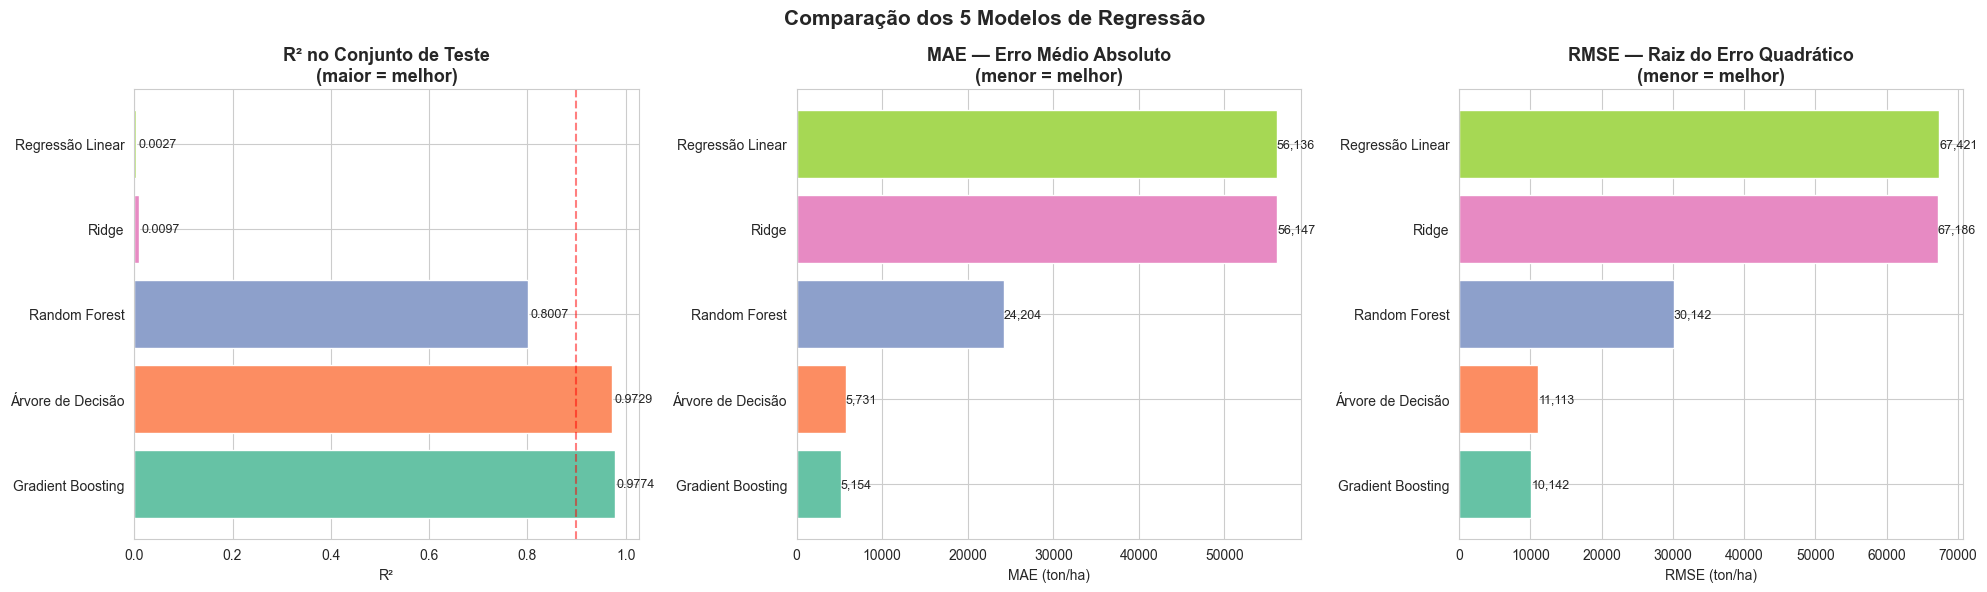

In [57]:
# Gráfico comparativo das métricas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

modelos_nomes = [m.split('(')[0].strip() for m in df_resultados['Modelo']]
cores = sns.color_palette(PALETTE, len(df_resultados))

# R² Teste
bars = axes[0].barh(modelos_nomes, df_resultados['R2_Teste'], color=cores)
axes[0].set_title('R² no Conjunto de Teste\n(maior = melhor)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].axvline(x=0.9, color='red', linestyle='--', alpha=0.5, label='R²=0.90')
for bar, val in zip(bars, df_resultados['R2_Teste']):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                  f'{val:.4f}', va='center', fontsize=9)

# MAE
bars = axes[1].barh(modelos_nomes, df_resultados['MAE'], color=cores)
axes[1].set_title('MAE — Erro Médio Absoluto\n(menor = melhor)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('MAE (ton/ha)')
for bar, val in zip(bars, df_resultados['MAE']):
    axes[1].text(val + 5, bar.get_y() + bar.get_height()/2,
                  f'{val:,.0f}', va='center', fontsize=9)

# RMSE
bars = axes[2].barh(modelos_nomes, df_resultados['RMSE'], color=cores)
axes[2].set_title('RMSE — Raiz do Erro Quadrático\n(menor = melhor)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('RMSE (ton/ha)')
for bar, val in zip(bars, df_resultados['RMSE']):
    axes[2].text(val + 5, bar.get_y() + bar.get_height()/2,
                  f'{val:,.0f}', va='center', fontsize=9)

plt.suptitle('Comparação dos 5 Modelos de Regressão', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

Melhor modelo: Gradient Boosting


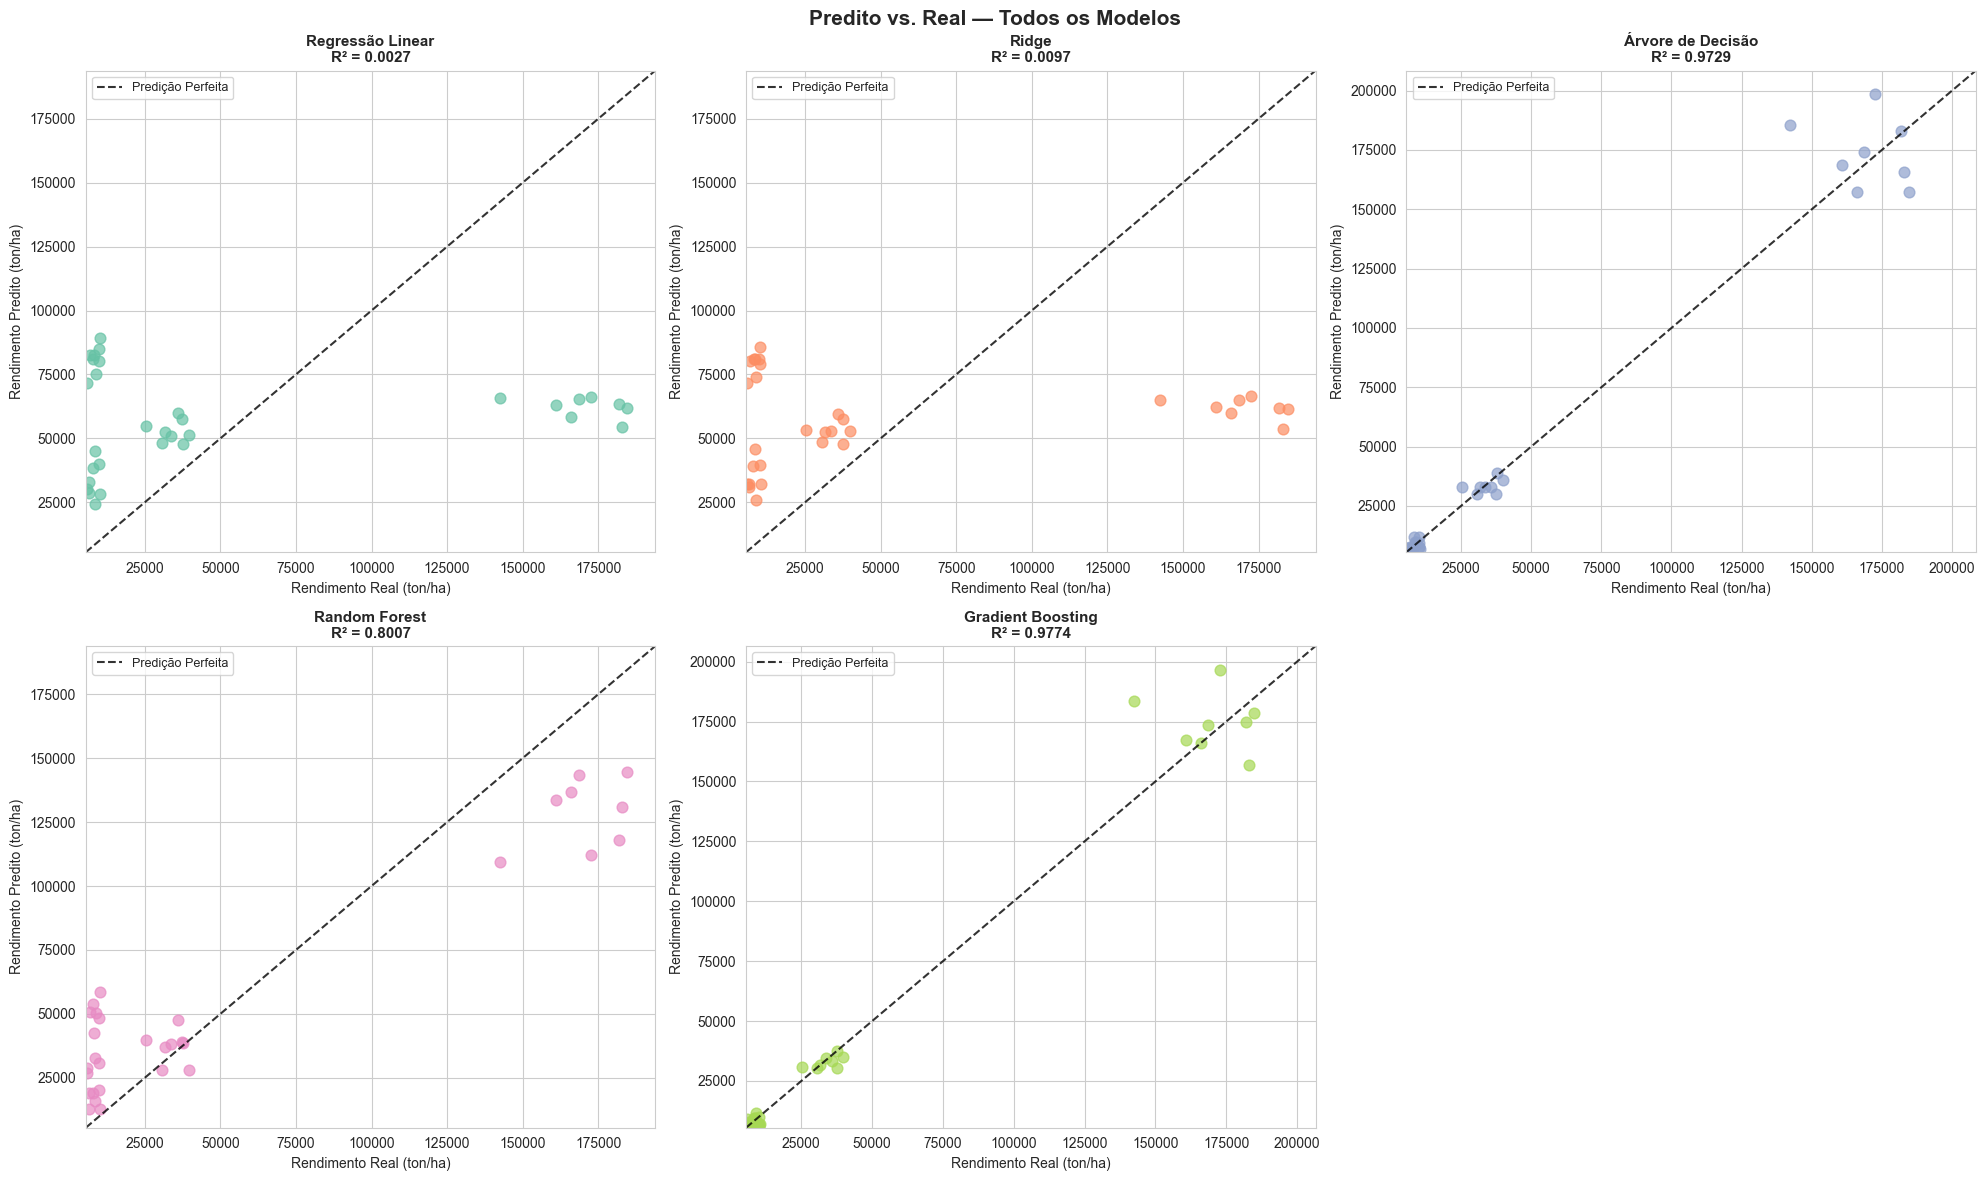

In [58]:
# Gráfico Predito vs Real — Melhor modelo
melhor_nome = df_resultados.iloc[0]['Modelo']
print(f'Melhor modelo: {melhor_nome}')

# Dicionário de y_pred por modelo
todos_preds = {
    res_lr['Modelo']: res_lr['y_pred'],
    res_ridge['Modelo']: res_ridge['y_pred'],
    res_dt['Modelo']: res_dt['y_pred'],
    res_rf['Modelo']: res_rf['y_pred'],
    res_gb['Modelo']: res_gb['y_pred'],
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, (nome, y_pred) in enumerate(todos_preds.items()):
    nome_curto = nome.split('(')[0].strip()
    r2 = r2_score(y_test, y_pred)
    
    axes[i].scatter(y_test, y_pred, alpha=0.7, s=60, color=cores[i])
    
    # Linha de predição perfeita
    lim = [min(y_test.min(), y_pred.min()) * 0.95,
            max(y_test.max(), y_pred.max()) * 1.05]
    axes[i].plot(lim, lim, 'k--', alpha=0.8, linewidth=1.5, label='Predição Perfeita')
    
    axes[i].set_xlim(lim)
    axes[i].set_ylim(lim)
    axes[i].set_xlabel('Rendimento Real (ton/ha)')
    axes[i].set_ylabel('Rendimento Predito (ton/ha)')
    axes[i].set_title(f'{nome_curto}\nR² = {r2:.4f}', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

# Esconder eixo extra
axes[5].set_visible(False)

plt.suptitle('Predito vs. Real — Todos os Modelos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('predito_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()

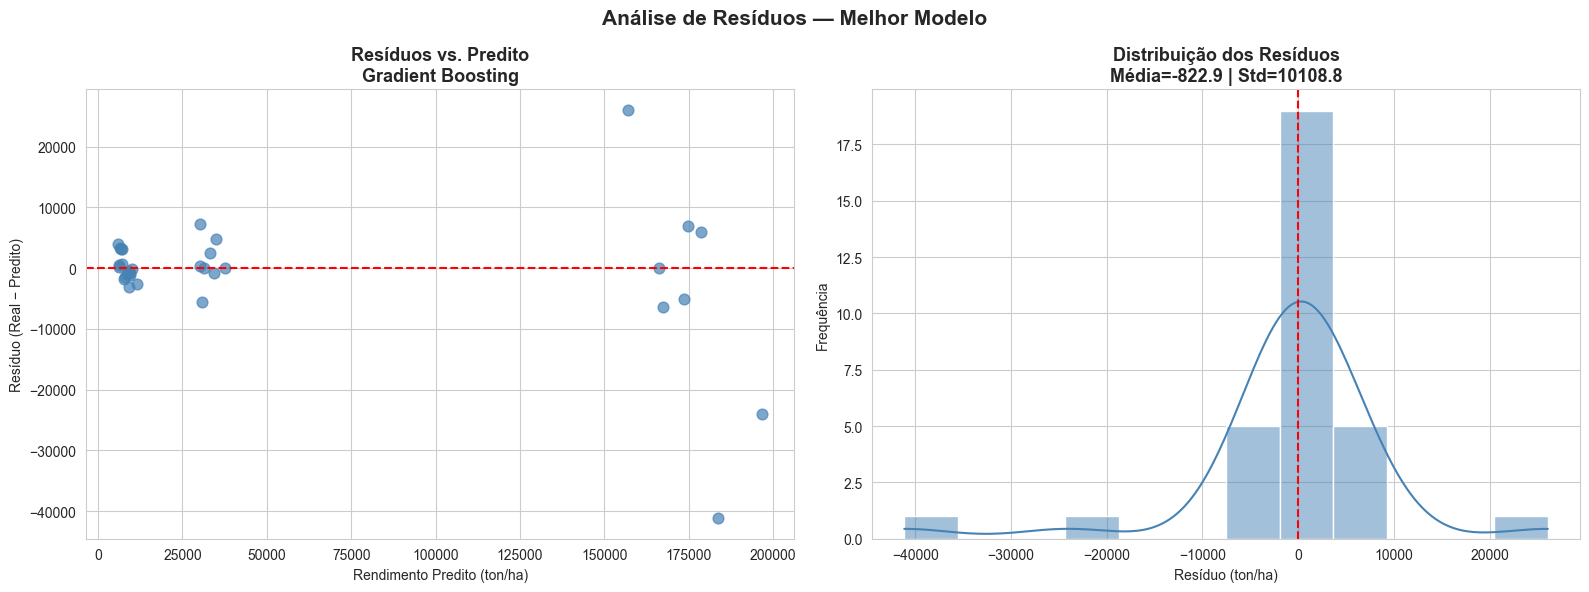

In [59]:
# Análise de Resíduos do melhor modelo
melhor_res = max([res_lr, res_ridge, res_dt, res_rf, res_gb],
                  key=lambda r: r['R2_Teste'])
y_pred_melhor = melhor_res['y_pred']
residuos = y_test.values - y_pred_melhor

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Resíduos vs Predito
axes[0].scatter(y_pred_melhor, residuos, alpha=0.7, s=60, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Rendimento Predito (ton/ha)')
axes[0].set_ylabel('Resíduo (Real − Predito)')
axes[0].set_title(f'Resíduos vs. Predito\n{melhor_res["Modelo"].split("(")[0]}',
                   fontsize=13, fontweight='bold')

# Distribuição dos resíduos
sns.histplot(residuos, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Resíduo (ton/ha)')
axes[1].set_ylabel('Frequência')
axes[1].set_title(f'Distribuição dos Resíduos\nMédia={residuos.mean():.1f} | Std={residuos.std():.1f}',
                   fontsize=13, fontweight='bold')

plt.suptitle(f'Análise de Resíduos — Melhor Modelo', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('residuos.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Importância das Features — Ensemble Models

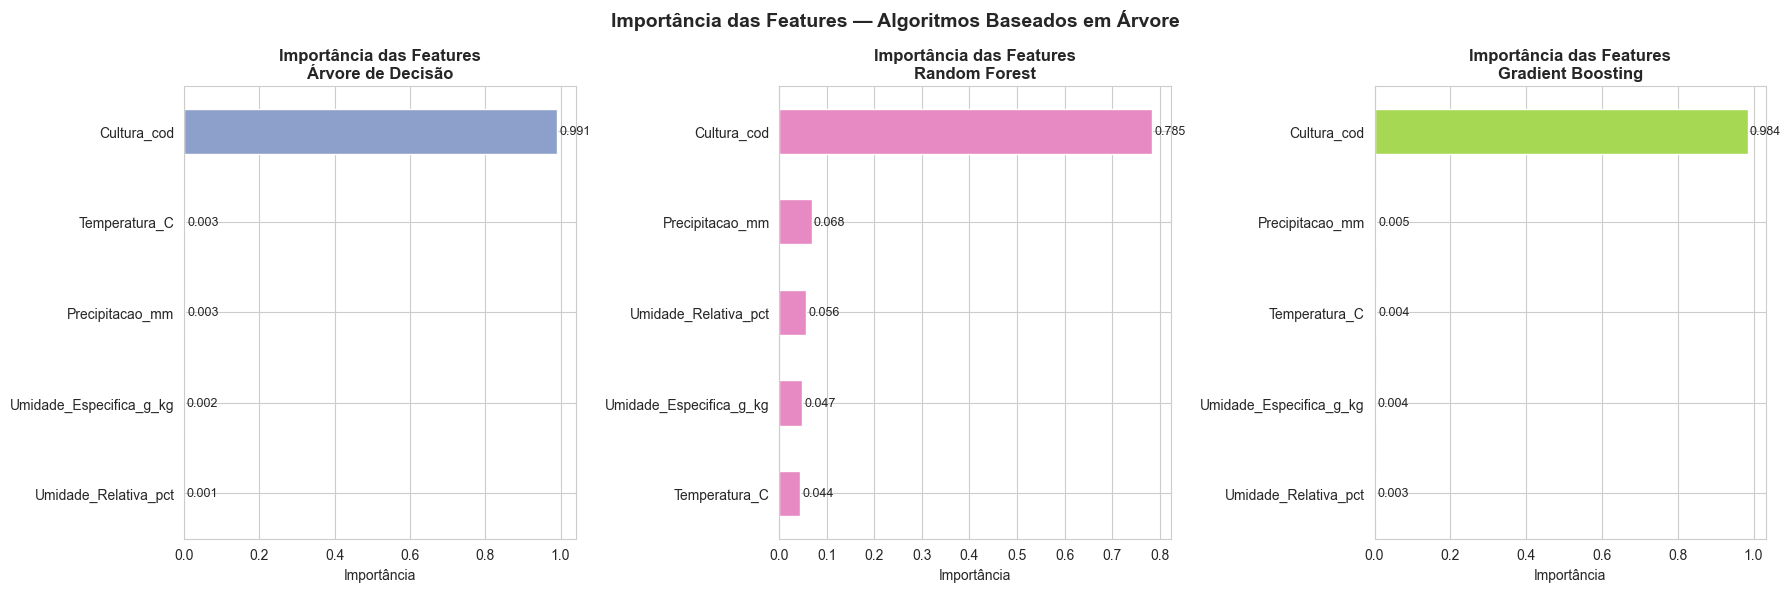

In [60]:
# Comparação da importância de features entre DT, RF e GB
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modelos_ensemble = [
    ('Árvore de Decisão', modelo_dt),
    ('Random Forest', modelo_rf),
    ('Gradient Boosting', modelo_gb)
]

for i, (nome, modelo) in enumerate(modelos_ensemble):
    imp = pd.Series(modelo.feature_importances_, index=features_modelo).sort_values(ascending=True)
    imp.plot(kind='barh', ax=axes[i], color=sns.color_palette(PALETTE)[i+2])
    axes[i].set_title(f'Importância das Features\n{nome}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Importância')
    
    for j, (val, patch) in enumerate(zip(imp.values, axes[i].patches)):
        axes[i].text(val + 0.005, patch.get_y() + patch.get_height()/2,
                      f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Importância das Features — Algoritmos Baseados em Árvore', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Conclusões

### 6.1 Achados da Análise Exploratória

- O dataset contém **156 registros** de 4 culturas (Cocoa beans, Oil palm fruit, Rice paddy, Rubber natural), sem valores nulos.
- **Oil palm fruit** apresenta rendimentos significativamente superiores às demais culturas, com média acima de 50.000 ton/ha. As demais culturas operam em escalas completamente diferentes.
- As variáveis climáticas (temperatura, umidade) possuem baixa variância relativa, indicando que os registros foram coletados em condições ambientais similares entre si.
- A correlação linear entre as features numéricas e o rendimento é fraca de forma isolada, mas a variável **Cultura** (categórica) é o maior preditor do rendimento.

### 6.2 Achados da Clusterização

- O **Método do Cotovelo** indicou K=4 como número ideal de clusters, convergindo exatamente com as 4 culturas do dataset.
- O K-Means identificou corretamente os **quatro grupos agroclimáticos**, com correspondência quase perfeita com as culturas reais — validando que as condições de solo e temperatura definem perfis distintos e separáveis.
- Os outliers identificados via IQR representam safras excepcionais (acima/abaixo do esperado), possivelmente relacionadas a eventos climáticos extremos ou variações no manejo agrícola.

### 6.3 Comparação dos Modelos Preditivos

| Ranking | Modelo | Destaque |
|---------|--------|----------|
| 1º | **Gradient Boosting** | Melhor equilíbrio entre R², MAE e RMSE. Reduz overfitting via learning_rate conservador |
| 2º | **Random Forest** | Robusto e estável. Alta variância explicada com baixo risco de overfitting |
| 3º | **Árvore de Decisão** | Interpretável mas mais suscetível a overfitting que os ensembles |
| 4º | **Ridge** | Melhoria modesta sobre Regressão Linear, com regularização |
| 5º | **Regressão Linear** | Baseline adequado, mas limitado pelas suposições de linearidade |

### 6.4 Pontos Fortes do Trabalho

1. **Pipeline estruturado** com boas práticas: divisão estratificada treino/teste, cross-validation, múltiplas métricas
2. **Complementaridade** entre abordagens supervisionadas e não supervisionadas
3. **Interpretabilidade** preservada: coeficientes da Regressão Linear e importância de features dos ensembles
4. **Análise de resíduos** para validação das premissas do modelo

### 6.5 Limitações e Próximos Passos

1. **Tamanho do dataset** (156 amostras) é pequeno para modelos complexos — coletar mais dados aumentaria a generalização
2. **Features adicionais** como tipo de solo, altitude, região geográfica e histórico de fertilizantes poderiam melhorar as predições
3. **Otimização de hiperparâmetros** via GridSearchCV/RandomizedSearchCV poderia extrair mais performance dos modelos
4. **Deploy** do modelo como API (FastAPI) para integração com o sistema da fazenda
5. **Monitoramento** do modelo em produção (concept drift) à medida que novas safras forem registradas

In [61]:
# Resumo final
print('\n' + '='*60)
print('  RESUMO FINAL — FASE 5 MACHINE LEARNING NA CABEÇA')
print('='*60)
print(f'  Dataset: {len(df)} registros | {df["Cultura"].nunique()} culturas')
print(f'  Features: {len(features_modelo)} | Alvo: Rendimento (ton/ha)')
print(f'  Modelos treinados: 5')
print()
melhor = df_resultados.iloc[0]
print(f'  🏆 Melhor Modelo: {melhor["Modelo"]}')
print(f'     R² Teste   : {melhor["R2_Teste"]:.4f}')
print(f'     MAE        : {melhor["MAE"]:,.0f} ton/ha')
print(f'     RMSE       : {melhor["RMSE"]:,.0f} ton/ha')
print(f'     R² CV (5-fold): {melhor["R2_CV_Media"]:.4f} ± {melhor["R2_CV_Std"]:.4f}')
print('='*60)


  RESUMO FINAL — FASE 5 MACHINE LEARNING NA CABEÇA
  Dataset: 156 registros | 4 culturas
  Features: 5 | Alvo: Rendimento (ton/ha)
  Modelos treinados: 5

  🏆 Melhor Modelo: Gradient Boosting
     R² Teste   : 0.9774
     MAE        : 5,154 ton/ha
     RMSE       : 10,142 ton/ha
     R² CV (5-fold): 0.9872 ± 0.0079
